In [1]:
from typing import Any, Sequence
from pathlib import Path

import numpy as np
from numpy.typing import NDArray
import matplotlib as mpl
from matplotlib.patches import Rectangle
from matplotlib.figure import Figure
from matplotlib.axes import Axes
import matplotlib.pyplot as plt

from darksun.show import map4biplot, biplot

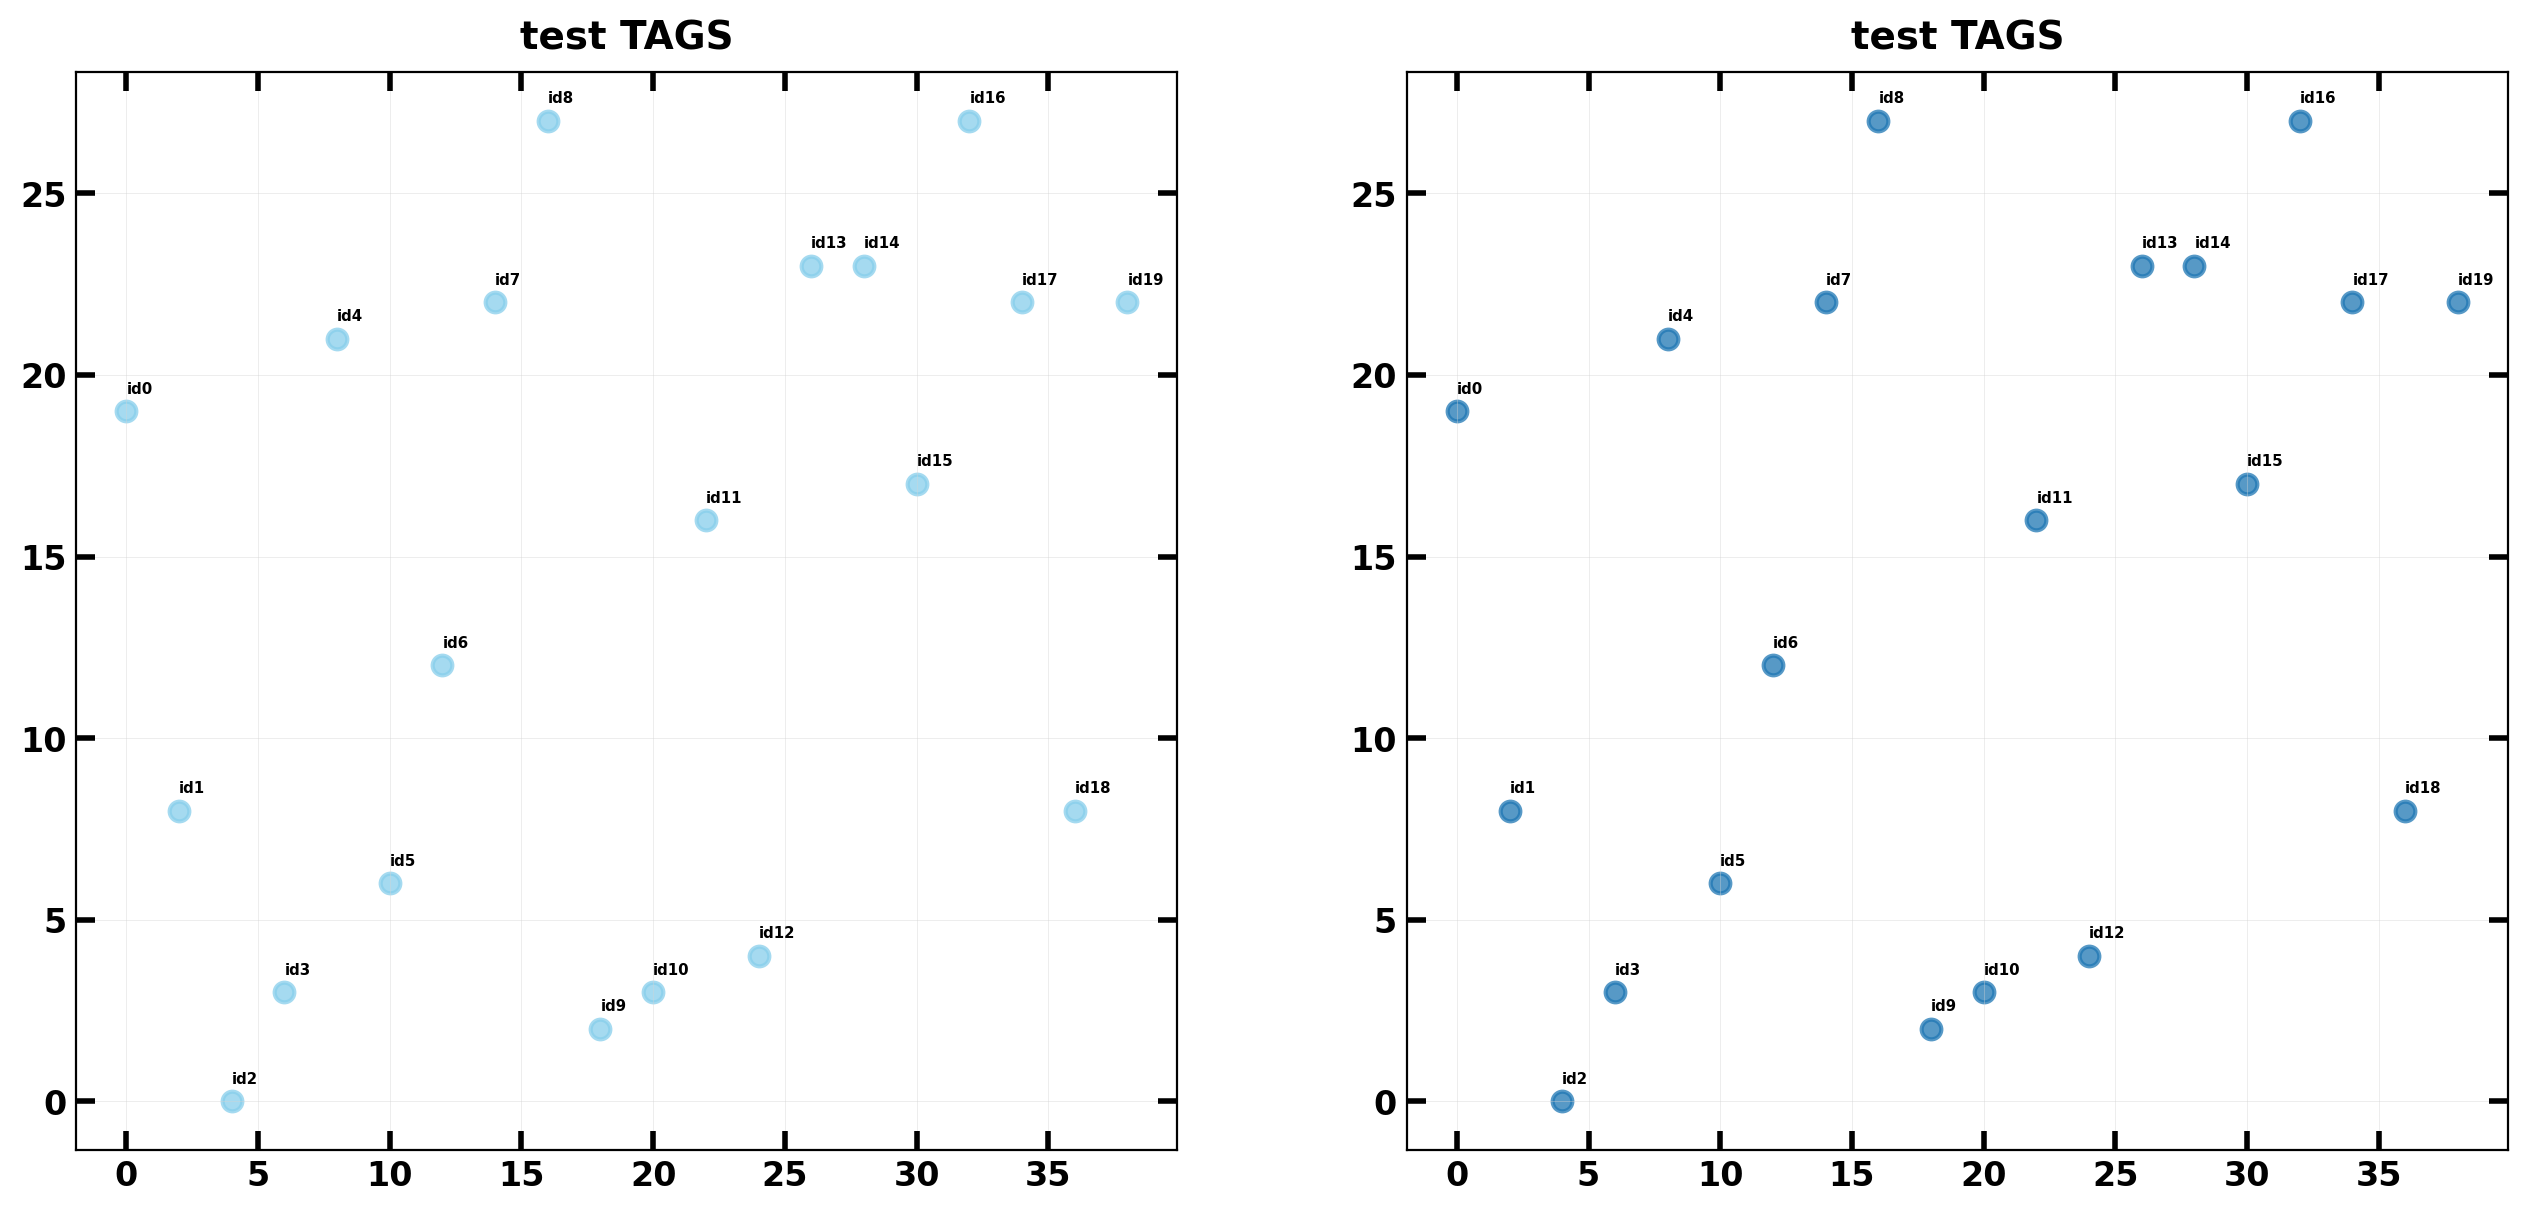

In [14]:
y = np.random.randint(0, 30, 20)
x = np.arange(0, 2 * len(y), 2)
tags = tuple(
    (f'id{idx}', i + 0.5, j) for idx, (i, j) in enumerate(tuple(zip(y, x)))
)
dmap1 = map4biplot(
    arrs=y,
    title='test TAGS',
    x=x,
    color='SkyBlue',
    style='scatter',
    tags=tags,
)
dmap2 = map4biplot(
    arrs=y,
    title='test TAGS',
    x=x,
    style='scatter',
    tags=tags,
)
biplot(dmap1, dmap2)

In [ ]:
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.optim import model_sky
from darksun.data import Log
from darksun.show import slices_plot, image_plot
from darksun.images import upscale, crop

def reconstruction_plot(
    true_sky: NDArray,
    log: Log,
    crp: tuple[int, int],
    camera: CodedMaskCamera,
    *,
    vignetting: bool = True,
    psfy: bool = True,
) -> None:
    """
    Displays the IROS reconstruction effect wrt the original decoded sky.

    Specifically, it shows:
        - IROS reconstructed source slices wrt the true sky
        - source slices residues
        - source profiles residues heatmap

    Args:
        true_sky (NDArray):
            True observed decoded sky.
        log (Log):
            Reconstructed sources database.
        crp (tuple[int, int]):
            Size of the cropping along (y, x).
        camera (CodedMaskCamera):
            CodedMaskCamera instance used for imaging and reconstruction.
        vignetting (bool, optional (default=`True`)):
            Simulates vignetting effects.
        psfy (bool, optional (default=`True`)):
            Simulates detector reconstruction effects.
    
    Notes:
        - A copy of `true_sky` is used to avoid memory overwrite.
    """
    true_sky_ = true_sky.copy()
    UPX, UPY = camera.upscale_f

    for source, sx, sy, f, x, y in zip(
        log.log['ID'],
        log.log['shift_x'],
        log.log['shift_y'],
        log.log['fluence'],
        log.log['x'],
        log.log['y'],
    ):
        POS = (y, x)

        # simulate source
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        # plot IROS vs True skies slices (profiles and residues)
        slices_plot(
            sky=(true_sky_, modeled),
            pos=POS,
            crp=crp,
            source=source,
            labels=('True', 'IROS'),
            cameraID=log.name,
        )
        slices_plot(
            sky=true_sky_ - modeled,
            pos=POS,
            crp=crp,
            source=source,
            ylabel='residues [ph]',
            cameraID=log.name,
        )

        # plot IROS vs True residues heatmaps
        CUT = (
            int(camera.specs['slit_deltay'] * UPY / camera.specs['mask_deltay']) + 1,
            int(camera.specs['slit_deltax'] * UPX / camera.specs['mask_deltax']) + 1,
        )
        F_UPY, F_UPX = 2, 5

        true_crp, modeled_crp = map(
            lambda x: crop(x, pos=POS, crp=CUT, strict=False),
            (true_sky_, modeled),
        )
        image_plot(
            arr=upscale(true_crp - modeled_crp, F_UPY, F_UPX) * np.prod((F_UPY, F_UPX)),
            title=f'True - IROS Residues {log.name}',
            cbarlabel='counts',
            cmap='bwr',
            extent=(-CUT[1] * F_UPX, CUT[1] * F_UPX, -CUT[0] * F_UPY, CUT[0] * F_UPY),
        )

        # remove source from True sky
        true_sky_ -= modeled